In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from joblib import dump
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix



In [87]:
# Load data

df = pd.read_csv("Telco_Customer_Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [88]:
df.shape

(7043, 21)

In [89]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [90]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [92]:
# Data Cleaning

df = df.drop("customerID", axis = 1)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors = 'coerce')
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

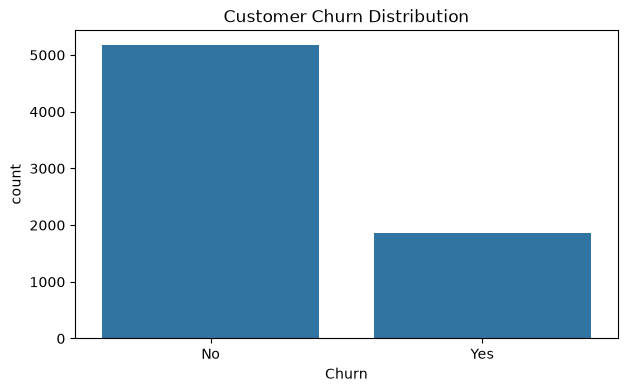

In [93]:
# Visualization

# Churn Distrtibution

plt.figure(figsize = (7,4))
sns.countplot(x = df["Churn"])
plt.title("Customer Churn Distribution")
plt.show()

This tells us the telecom company retains most customers, but a smaller group leaves. The target variable shows moderate class imbalance. Since predicting only the majority class can produce misleading accuracy.

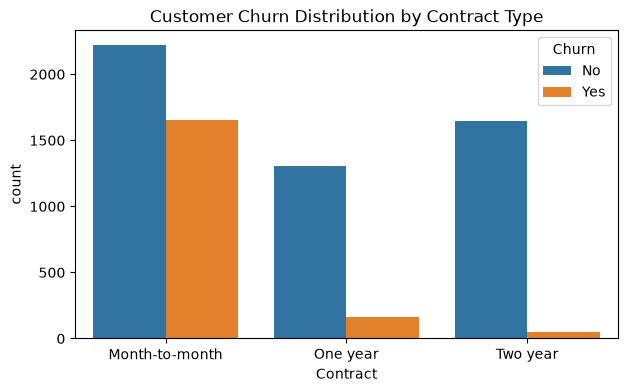

In [94]:
# Customer Churn by Contract Type

plt.figure(figsize = (7,4))
sns.countplot(x = df["Contract"], hue = "Churn", data = df)
plt.title("Customer Churn Distribution by Contract Type")
plt.show()

This visualization suggests that contract type is an important feature influencing customer churn. There is a clear inverse relationship that there is lower churn probability for longer contract duration.

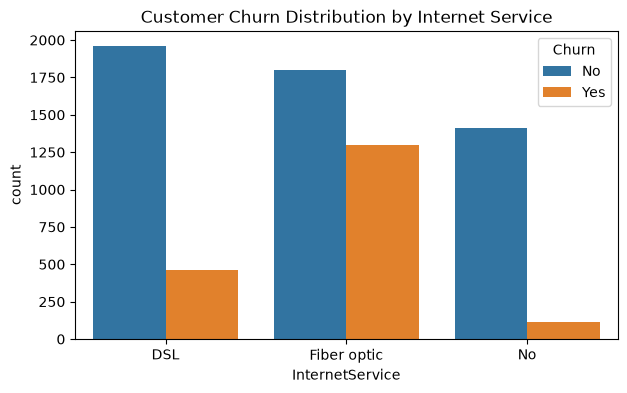

In [95]:
# Customer Churn by Internet Service

plt.figure(figsize = (7,4))
sns.countplot(x = df["InternetService"], hue = "Churn", data = df)
plt.title("Customer Churn Distribution by Internet Service")
plt.show()

This chart shows the relationship between Internet Service Type and Customer Churn. Internet service type appears to influence customer retention.
* Fiber optic customers are at greater churn risk
* DSL customers show better retention
* Customers without internet service are least likely to leave

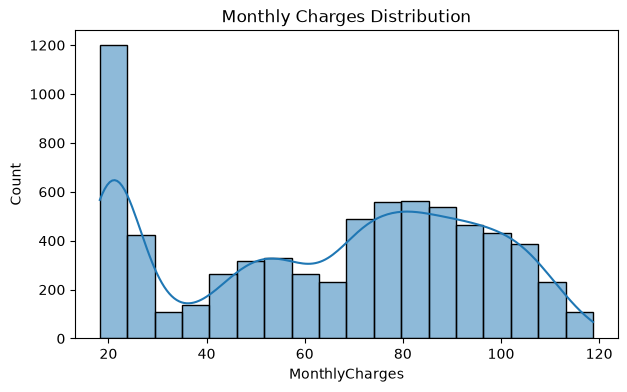

In [96]:
# Monthly Charges Distribution

plt.figure(figsize = (7,4))
sns.histplot(df["MonthlyCharges"], kde = True)
plt.title("Monthly Charges Distribution")
plt.show()
    

The Monthly Charges distribution shows two customer segments: one group concentrated at lower charges and another at medium-to-high charges. The feature is bimodal, indicating different pricing plans among customers. Since monthly charges vary considerably across customers, this variable may contribute significantly to predicting customer churn.

In [97]:
# Skewness Check

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
print("\nSkewness\n")
print(df[num_cols].skew())


Skewness

tenure            0.239540
MonthlyCharges   -0.220524
TotalCharges      0.963789
dtype: float64


In [98]:
# Target Encoding

encoder = LabelEncoder()
df["Churn"] = encoder.fit_transform(df["Churn"])


In [99]:
# Feature Importance

print("\nFeature Importance\n")

global_mean = df["Churn"].mean()
cat_cols = (df.select_dtypes(include = "object").columns)

remove_cols = []
for col in cat_cols:
    churn_rate = (df.groupby(col)["Churn"].mean())
    risk = (churn_rate / global_mean)

    print("\n", col)
    print(round(risk, 2))

    if(risk.max() - risk.min()) < 0.10:
        remove_cols.append(col)

print("\nRemove\n")
print(remove_cols)


Feature Importance


 gender
gender
Female    1.01
Male      0.99
Name: Churn, dtype: float64

 Partner
Partner
No     1.24
Yes    0.74
Name: Churn, dtype: float64

 Dependents
Dependents
No     1.18
Yes    0.58
Name: Churn, dtype: float64

 PhoneService
PhoneService
No     0.94
Yes    1.01
Name: Churn, dtype: float64

 MultipleLines
MultipleLines
No                  0.94
No phone service    0.94
Yes                 1.08
Name: Churn, dtype: float64

 InternetService
InternetService
DSL            0.71
Fiber optic    1.58
No             0.28
Name: Churn, dtype: float64

 OnlineSecurity
OnlineSecurity
No                     1.57
No internet service    0.28
Yes                    0.55
Name: Churn, dtype: float64

 OnlineBackup
OnlineBackup
No                     1.50
No internet service    0.28
Yes                    0.81
Name: Churn, dtype: float64

 DeviceProtection
DeviceProtection
No                     1.47
No internet service    0.28
Yes                    0.85
Name: Churn, dtype: 

C:\Users\PRIYA SRIVASTAVA\AppData\Local\Temp\ipykernel_16188\1706558168.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = (df.select_dtypes(include = "object").columns)


Feature Important Analysis:
To identify influential variables before model training, feature importance analysis was performed using risk ratio.
where 
* risk ratio = 1, feature has little effect on churn
* risk ratio > 1, category has higher churn tendency
* risk ratio < 1, category has lower churn tendency

features showing very small differences across categories were considered less informative and removed


In [100]:
# Feature and Target Split

x = df.drop(columns = ["Churn","gender","PhoneService"])
y = df["Churn"]

In [101]:
# One Hot Encoding for Input Features

x = pd.get_dummies(x, drop_first= True)


In [102]:
# Train Test Split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify=y)

In [103]:
# Scaling

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

## WITHOUT SMOTE ##

In [104]:
# Logistic Regression

lr_model = LogisticRegression(max_iter = 1000,random_state=42)

#Train
lr_model.fit(x_train,y_train)

#Prediction
lr_pred = lr_model.predict(x_test)

print("\nClassification Report:\n", classification_report(y_test, lr_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, lr_pred))



Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Confusion Matrix:
 [[926 109]
 [165 209]]


In [105]:
# Decision Tree Classifier

dt_model = DecisionTreeClassifier()

# Train
dt_model.fit(x_train, y_train)

# Prediction
dt_pred = dt_model.predict(x_test)

print("\nClassification Report:\n", classification_report(y_test, dt_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, dt_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.82      0.82      1035
           1       0.51      0.52      0.51       374

    accuracy                           0.74      1409
   macro avg       0.67      0.67      0.67      1409
weighted avg       0.74      0.74      0.74      1409


Confusion Matrix:
 [[849 186]
 [181 193]]


In [106]:
# Random Forest Classifier

rf_model = RandomForestClassifier()

# Train
rf_model.fit(x_train, y_train)

# Prediction
rf_pred = rf_model.predict(x_test)

print("\nClassification Report:\n", classification_report(y_test, rf_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.61      0.51      0.56       374

    accuracy                           0.78      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.77      0.78      0.78      1409


Confusion Matrix:
 [[916 119]
 [184 190]]


In [107]:
# SVC

svc_model = SVC()

# Train
svc_model.fit(x_train, y_train)

# Prediction
svc_pred = svc_model.predict(x_test)

print("\nClassification Report:\n", classification_report(y_test, svc_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, svc_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.80      0.79      1409


Confusion Matrix:
 [[933 102]
 [186 188]]


In [108]:
# K Neighbors Classifier

knn_model = KNeighborsClassifier()

# Train
knn_model.fit(x_train, y_train)

# Prediction
knn_pred = knn_model.predict(x_test)

print("\nClassification Report:\n", classification_report(y_test, knn_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, knn_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.83      1035
           1       0.54      0.49      0.51       374

    accuracy                           0.75      1409
   macro avg       0.68      0.67      0.67      1409
weighted avg       0.75      0.75      0.75      1409


Confusion Matrix:
 [[878 157]
 [190 184]]


In [109]:
# Class Balancing

print("\nBefore SMOTE\n")
print(y_train.value_counts())

sm = SMOTE(random_state = 42)
x_train, y_train = (sm.fit_resample(x_train, y_train))
print("\nAfter SMOTE\n")
print(y_train.value_counts())




Before SMOTE

Churn
0    4139
1    1495
Name: count, dtype: int64

After SMOTE

Churn
0    4139
1    4139
Name: count, dtype: int64


## WITH SMOTE ##

In [110]:
# Models

# Logistic Regression

lr_ws_model = LogisticRegression(max_iter = 1000,random_state=42)

#Train
lr_ws_model.fit(x_train,y_train)

#Prediction
lr_ws_pred = lr_ws_model.predict(x_test)

print("\nClassification Report:\n", classification_report(y_test, lr_ws_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, lr_ws_pred))



Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409


Confusion Matrix:
 [[743 292]
 [ 76 298]]


In [111]:
# Decision Tree Classifier

dt_ws_model = DecisionTreeClassifier()

# Train
dt_ws_model.fit(x_train, y_train)

# Prediction
dt_ws_pred = dt_ws_model.predict(x_test)

print("\nClassification Report:\n", classification_report(y_test, dt_ws_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, dt_ws_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.77      0.80      1035
           1       0.47      0.55      0.51       374

    accuracy                           0.71      1409
   macro avg       0.65      0.66      0.65      1409
weighted avg       0.73      0.71      0.72      1409


Confusion Matrix:
 [[800 235]
 [167 207]]


In [112]:
# Random Forest Classifier

rf_ws_model = RandomForestClassifier()

# Train
rf_ws_model.fit(x_train, y_train)

# Prediction
rf_ws_pred = rf_ws_model.predict(x_test)

print("\nClassification Report:\n", classification_report(y_test, rf_ws_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_ws_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.83      0.84      1035
           1       0.56      0.59      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.77      0.77      0.77      1409


Confusion Matrix:
 [[864 171]
 [152 222]]


In [113]:
# SVC

svc_ws_model = SVC()

# Train
svc_ws_model.fit(x_train, y_train)

# Prediction
svc_ws_pred = svc_ws_model.predict(x_test)

print("\nClassification Report:\n", classification_report(y_test, svc_ws_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, svc_ws_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.77      0.82      1035
           1       0.53      0.72      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409


Confusion Matrix:
 [[794 241]
 [104 270]]


In [114]:
# K Neighbors Classifier

knn_ws_model = KNeighborsClassifier()

# Train
knn_ws_model.fit(x_train, y_train)

# Prediction
knn_ws_pred = knn_ws_model.predict(x_test)

print("\nClassification Report:\n", classification_report(y_test, knn_ws_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, knn_ws_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.70      0.77      1035
           1       0.45      0.67      0.54       374

    accuracy                           0.69      1409
   macro avg       0.65      0.69      0.65      1409
weighted avg       0.75      0.69      0.71      1409


Confusion Matrix:
 [[724 311]
 [122 252]]


In [115]:
# Accuracy Comparison Table

comparison = pd.DataFrame({
    "Model" : [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVC",
        "KNN"
    ],

    "Without SMOTE" : [
        round(accuracy_score(y_test, lr_pred),2),
        round(accuracy_score(y_test, dt_pred),2),
        round(accuracy_score(y_test, rf_pred),2),
        round(accuracy_score(y_test, svc_pred),2),
        round(accuracy_score(y_test, knn_pred),2),
    ],

    "With SMOTE" : [
        round(accuracy_score(y_test, lr_ws_pred),2),
        round(accuracy_score(y_test, dt_ws_pred),2),
        round(accuracy_score(y_test, rf_ws_pred),2),
        round(accuracy_score(y_test, svc_ws_pred),2),
        round(accuracy_score(y_test, knn_ws_pred),2),
    ]
    })
print("\nModel Accuracy Comparison\n")
comparison



Model Accuracy Comparison



,Model,Without SMOTE,With SMOTE
0,Logistic Regression,0.81,0.74
1,Decision Tree,0.74,0.71
2,Random Forest,0.78,0.77
3,SVC,0.80,0.76
4,KNN,0.75,0.69


The original dataset was imbalance was not severe enough to require oversampling. Becuase SMOTE introduced synthetic churn samples that reduced overall classification accuracy.
Multiple classification models were trained with and without SMOTE to evaluate the impact of class balancing. Results showed that oversampling reduced overall accuracy across all models. Logistic Regression achieved best performance with 81% accuarcy and was selected as the final model for deployment.

In [116]:
# Select Model

final_model = lr_model

In [117]:
# Save Final Model

dump(final_model, "model.pkl")

['model.pkl']

In [118]:
# Save Sacler and Encoder

dump(x.columns.tolist(), "columns.pkl")

dump(scaler, "scaler.pkl")

dump(encoder, "encoder.pkl")

['encoder.pkl']